# Simulación del Hamiltoniano de Ising

Vamos a utilizar las herramientas de la computación cuántica para poder realizar simulaciones del Hamiltoniano de Ising con campo transverso:



In [1]:
from funciones_ising_hackathon import *
import numpy as np
import matplotlib.pyplot as plt

Vamos a implementar el Hamiltoniano Trotterizado y compararlo con el Hamiltoniano analítico obtenido por Diagonalización:

In [2]:
J = 1.0
h = 0.5
n_q = 4
r = 10
t = 1.0

psi_trotter = H_trott1_c(  # Hamiltoniano Trotterizado
    J=J,
    h=h,
    n_q=n_q,
    r=r,
    t=t
)

print(psi_trotter)

Statevector([-0.38110897-0.82031334j, -0.096383  -0.13714844j,
             -0.09641597-0.13698581j,  0.00290174-0.11657033j,
             -0.09886633-0.14120471j, -0.0187001 -0.0100051j ,
              0.00402522-0.11857106j,  0.04788949-0.03163649j,
             -0.12035125-0.11058514j, -0.02136804-0.11313144j,
             -0.02108316-0.00230131j,  0.03910316-0.04207165j,
              0.00187532-0.11555905j,  0.04697226-0.03727477j,
              0.04524244-0.02874128j,  0.00340511+0.03156357j],
            dims=(2, 2, 2, 2))


In [3]:
psi_exacta = evolve_tfim_exact(  #Hamiltoniano exacto
    t=t,
    h=h,
    J=J,
    n_qubits=n_q,
    r=r,
    periodic=True
)

Para poder comparar ambos valores necesitamos encontrar una métrica que nos relaciones como podemos conectar ambos valores. La métrica que tiene mas sentido es la Fidelidad de estados cuánticos, que nos indica que tanto se parece un estado cuántico a otro. El valor matemático de la fidelidad es:

$$F=|\langle \psi_{exacta}|\psi_{trotterizada}\rangle|^2$$

Veamos para los parámetros dados antes, como se visualiza la Fidelidad

In [4]:
fidelidad = abs(
    psi_exacta.inner(psi_trotter)
)**2

print(f"Fidelidad: {fidelidad:.8f}")

Fidelidad: 0.99501046


Ahora, para verificar la convergencia del valor r, vamos a iterarlo por número de pasos y graficarlo:

In [5]:
J = 1.0
h = 1.0
n_q = 6
t = 1.0

valores_r = [1, 2,3,4, 5,8, 10, 20, 50]

psi_exacta = evolve_tfim_exact(
    t=t,
    h=h,
    J=J,
    n_qubits=n_q,
    r=1,
    periodic=True
)

for r in valores_r:
    psi_trotter = H_trott1_c(
        J=J,
        h=h,
        n_q=n_q,
        r=r,
        t=t
    )

    fidelidad = abs(
        psi_exacta.inner(psi_trotter)
    )**2

    print(
        f"r = {r:2d} | "
        f"dt = {t/r:.4f} | "
        f"F = {fidelidad:.8f}"
    )

r =  1 | dt = 1.0000 | F = 0.07157111
r =  2 | dt = 0.5000 | F = 0.59106062
r =  3 | dt = 0.3333 | F = 0.81236192
r =  4 | dt = 0.2500 | F = 0.89413920
r =  5 | dt = 0.2000 | F = 0.93236443
r =  8 | dt = 0.1250 | F = 0.97376072
r = 10 | dt = 0.1000 | F = 0.98326271
r = 20 | dt = 0.0500 | F = 0.99584928
r = 50 | dt = 0.0200 | F = 0.99933963


Podemos graficar la evolución de la convergencia facilmente:

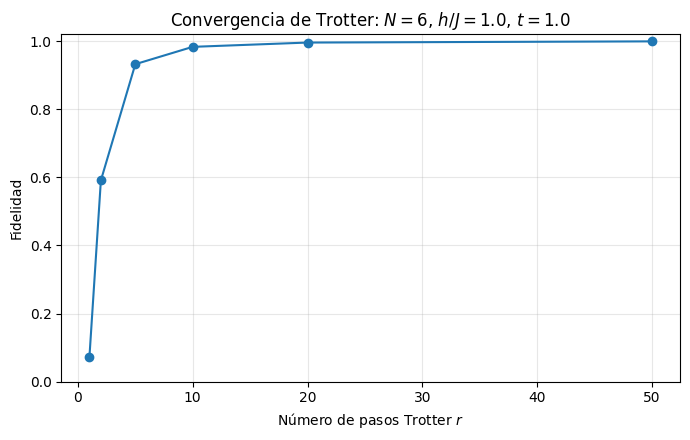

In [6]:
J = 1.0
h = 1.0
n_q = 6
t = 1.0

valores_r = np.array([1, 2, 5, 10, 20, 50])
fidelidades = []

psi_exacta = evolve_tfim_exact(
    t=t,
    h=h,
    J=J,
    n_qubits=n_q,
    r=1,
    periodic=True
)

for r in valores_r:
    psi_trotter = H_trott1_c(
        J=J,
        h=h,
        n_q=n_q,
        r=int(r),
        t=t
    )

    F = abs(
        psi_exacta.inner(psi_trotter)
    )**2

    fidelidades.append(F)

plt.figure(figsize=(7, 4.5))

plt.plot(
    valores_r,
    fidelidades,
    marker="o"
)

plt.xlabel("Número de pasos Trotter $r$")
plt.ylabel("Fidelidad")
plt.title(
    rf"Convergencia de Trotter: "
    rf"$N={n_q}$, $h/J={h/J}$, $t={t}$"
)

plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Veamos la degradación del modelo con el aumento del tamaño de la cadena de espines y si esto acaba afectando el sistema

In [7]:
J = 1.0
h = 1.0
t = 1.0
r = 10

tamanos = [4, 6, 8, 10, 12] #Expandir esto utilizando simuladores para evitar que se demore demasiado el cálculo de la fidelidad
fidelidades = []

for n_q in tamanos:
    psi_exacta = evolve_tfim_exact(
        t=t,
        h=h,
        J=J,
        n_qubits=n_q,
        r=1,
        periodic=True
    )

    psi_trotter = H_trott1_c(
        J=J,
        h=h,
        n_q=n_q,
        r=r,
        t=t
    )

    F = abs(
        psi_exacta.inner(psi_trotter)
    )**2

    fidelidades.append(F)

    print(
        f"N = {n_q:2d} | "
        f"F = {F:.8f}"
    )

N =  4 | F = 0.98554828
N =  6 | F = 0.98326271
N =  8 | F = 0.97937046
N = 10 | F = 0.97544195
N = 12 | F = 0.97153081


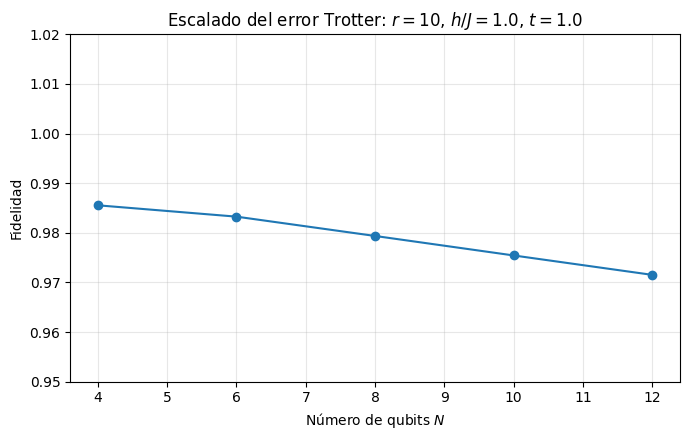

In [8]:
plt.figure(figsize=(7, 4.5))

plt.plot(
    tamanos,
    fidelidades,
    marker="o"
)

plt.xlabel("Número de qubits $N$")
plt.ylabel("Fidelidad")
plt.title(
    rf"Escalado del error Trotter: "
    rf"$r={r}$, $h/J={h/J}$, $t={t}$"
)

plt.ylim(0.95, 1.02)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

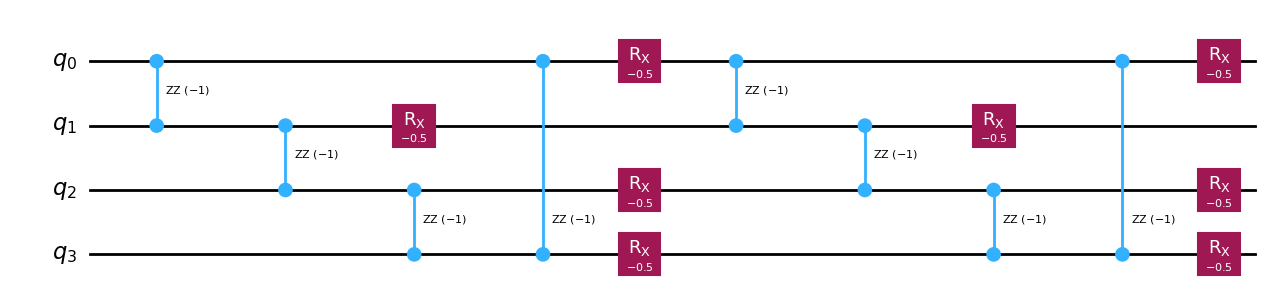

In [9]:
qc = circuito_tfim_trotter_cerrado(
    J=1.0,
    h=0.5,
    n_q=4,
    r=2,
    t=1.0
)

qc.draw("mpl")

In [10]:
print("Profundidad:", qc.depth())
print("Número total de operaciones:", qc.size())
print("Conteo de compuertas:", qc.count_ops())

Profundidad: 10
Número total de operaciones: 16
Conteo de compuertas: OrderedDict([('rzz', 8), ('rx', 8)])


Una vez ya tengamos esto, veamos como evoluciona la dinámica de los observables cuánticos despues de esto.

In [11]:
J = 1.0
h = 0.5
n_q = 6
r = 20
t = 1.0

psi_t = evolucion_tfim_trotter_cerrada(
    J=J,
    h=h,
    n_q=n_q,
    r=r,
    t=t
)

In [12]:
Mz = magnetizacion_z(n_q)

Czz = correlacion_zz_vecinos_cerrada(n_q)

In [13]:
mz = psi_t.expectation_value(Mz)
czz = psi_t.expectation_value(Czz)

mz = float(np.real_if_close(mz))
czz = float(np.real_if_close(czz))

print(f"<Mz>  = {mz:.8f}")
print(f"<Czz> = {czz:.8f}")

<Mz>  = 0.86772074
<Czz> = 0.81989909


Revisemos el caso $t=0$

In [14]:
psi_0 = evolucion_tfim_trotter_cerrada(
    J=1.0,
    h=0.5,
    n_q=6,
    r=1,
    t=0.0
)

print(
    float(np.real_if_close(
        psi_0.expectation_value(magnetizacion_z(6))
    ))
)

print(
    float(np.real_if_close(
        psi_0.expectation_value(
            correlacion_zz_vecinos_cerrada(6)
        )
    ))
)

0.9999999999999999
0.9999999999999999


Ahora veamos como evoluciona el estado:

In [25]:
datos = barrido_temporal_tfim_trotter_cerrado(
    J=1.0,
    h=2.0,
    n_q=6,
    r=1000,
    t_min=0.0,
    t_max=20.0,
    puntos=101
)

In [26]:
print(datos["tiempos"][:5])
print(datos["mz"][:5])
print(datos["czz"][:5])

[0.  0.2 0.4 0.6 0.8]
[ 1.          0.71113865  0.11532807 -0.37057648 -0.53192386]
[1.         0.51101717 0.14661556 0.47295114 0.57480559]


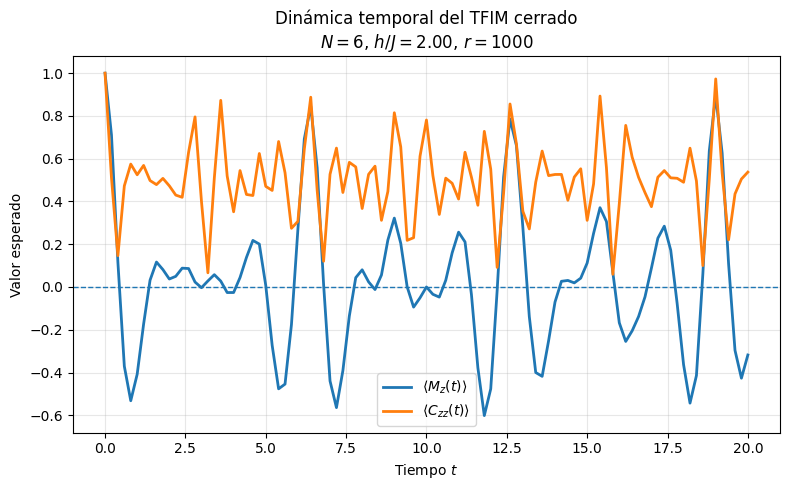

In [27]:
tiempos = datos["tiempos"]
mz = datos["mz"]
czz = datos["czz"]

plt.figure(figsize=(8, 5))

plt.plot(
    tiempos,
    mz,
    linewidth=2,
    label=r"$\langle M_z(t)\rangle$"
)

plt.plot(
    tiempos,
    czz,
    linewidth=2,
    label=r"$\langle C_{zz}(t)\rangle$"
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(r"Tiempo $t$")
plt.ylabel("Valor esperado")

plt.title(
    rf"Dinámica temporal del TFIM cerrado"
    "\n"
    rf"$N={datos['n_q']}$, "
    rf"$h/J={datos['h']/datos['J']:.2f}$, "
    rf"$r={datos['r']}$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
regimenes = {
    "Ferromagnético": 0.5,
    "Cercano al crítico": 1.0,
    "Paramagnético": 2.0
}

resultados = {}

for nombre, h in regimenes.items():

    resultados[nombre] = (
        barrido_temporal_tfim_trotter_cerrado(
            J=1.0,
            h=h,
            n_q=6,
            r=40,
            t_min=0.0,
            t_max=15.0,
            puntos=101
        )
    )

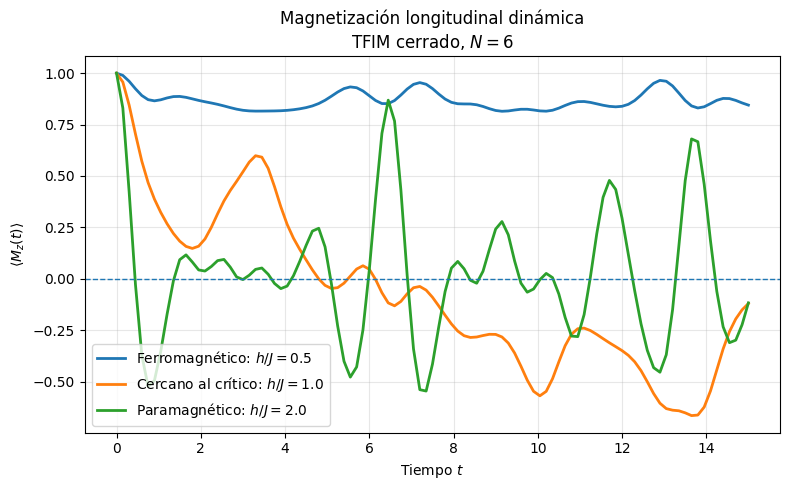

In [31]:
plt.figure(figsize=(8, 5))

for nombre, datos in resultados.items():

    plt.plot(
        datos["tiempos"],
        datos["mz"],
        linewidth=2,
        label=(
            rf"{nombre}: "
            rf"$h/J={datos['h']/datos['J']:.1f}$"
        )
    )

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel(r"Tiempo $t$")
plt.ylabel(r"$\langle M_z(t)\rangle$")
plt.title(
    r"Magnetización longitudinal dinámica"
    "\n"
    r"TFIM cerrado, $N=6$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

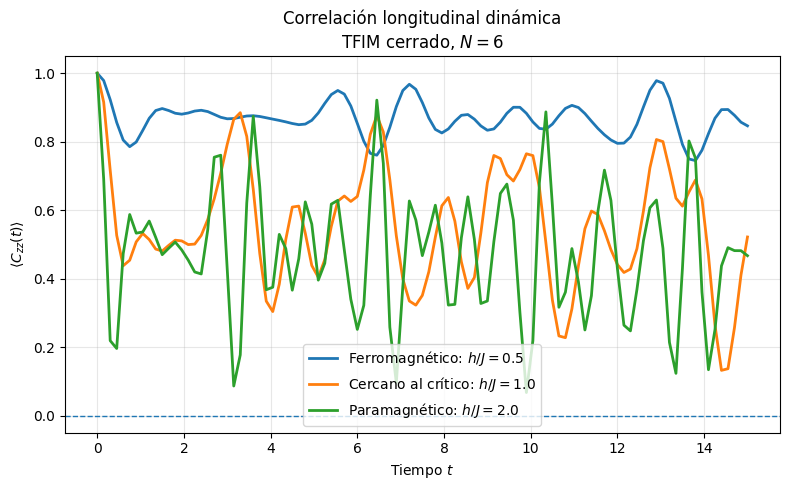

In [32]:
plt.figure(figsize=(8, 5))

for nombre, datos in resultados.items():

    plt.plot(
        datos["tiempos"],
        datos["czz"],
        linewidth=2,
        label=(
            rf"{nombre}: "
            rf"$h/J={datos['h']/datos['J']:.1f}$"
        )
    )

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xlabel(r"Tiempo $t$")
plt.ylabel(r"$\langle C_{zz}(t)\rangle$")
plt.title(
    r"Correlación longitudinal dinámica"
    "\n"
    r"TFIM cerrado, $N=6$"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()